### Recurrent Neural Network (LSTM, V2)

This is a basic convolutional approach to sequence prediction using convolutions through TensorFlow!

We begin by important any relevant packages, modules, and the DataProcessor class (for our pre-processed data). Then we get our dataset ready.

In [1]:
import os, sys
sys.path.append(os.path.abspath('..'))  # add parent directory to sys.path
from data_cleanup import DataProcessor
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Define the windowing parameters
# Use 24 hours of history
INPUT_WINDOW = 24  
# Predict the next 24 hours
OUTPUT_WINDOW = 24 

# Initialize the class
processor = DataProcessor(input_steps=INPUT_WINDOW, output_steps=OUTPUT_WINDOW)

# Run the pipeline
(X_train, y_train), (X_val, y_val), (X_test, y_test) = processor.load_and_process_data()

# Check the final shapes
print("\n--- Final Data Shapes ---")
print(f"X_train shape: {X_train.shape}  | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}     | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}    | y_test shape:  {y_test.shape}")

2025-11-24 18:26:34.773424: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Step 1/5: Fetching, cleaning, and engineering features...


/Users/felipejaracaceres/Documents/UCD/Machine Learning/ECS171G13/venv/lib/python3.11/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
/Users/felipejaracaceres/Documents/UCD/Machine Learning/ECS171G13/data_cleanup.py:135: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Step 2/5: Resampling data to hourly and setting 'Global_active_power' as target...


/Users/felipejaracaceres/Documents/UCD/Machine Learning/ECS171G13/data_cleanup.py:175: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').agg(agg_dict)


Step 3/5: Splitting data and applying scaler...
Step 4/5: Creating time-series windows...
Step 5/5: Data processing complete.

--- Final Data Shapes ---
X_train shape: (25880, 24, 8)  | y_train shape: (25880, 24)
X_val shape:   (3577, 24, 8)     | y_val shape:   (3577, 24)
X_test shape:  (4991, 24, 8)    | y_test shape:  (4991, 24)


/Users/felipejaracaceres/Documents/UCD/Machine Learning/ECS171G13/data_cleanup.py:176: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill')


Next, we want to build the model itself. Keras makes this very simple at a high-level, so tuning is also easy to do.

In [2]:
# Initialize the "order" of layers to be inserted. Will be a simple sequence.
model = Sequential()

# Add the first layer, which is an LSTM layer. We will choose to have 64 neurons, which sets the dimensionality seen
# throughout the LSTM layer.   
model.add(LSTM(units=64, return_sequences=True, input_shape=(24, 8)))

# Add a dropout layer to set some neurons to 0 for regularization. This prevents overfitting
model.add(Dropout(0.2))

# Add another LSTM layer but with 32 neurons.
model.add(LSTM(32))

# Add another dropout layer.
model.add(Dropout(0.2))

# The second layer is the final layer. This is a Dense one so we get 24 hours to predict.
model.add(Dense(OUTPUT_WINDOW))

# Set some parameters for how model will be optimized and how loss is calculated.
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

/Users/felipejaracaceres/Documents/UCD/Machine Learning/ECS171G13/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Now we want to fit the model, train it, and determine an error metric.

In [3]:
# Early stopping to prevent overfitting
es = EarlyStopping(patience=5, restore_best_weights=True)

# Create a checkpoints directory and define the checkpoint path
os.makedirs('checkpoints', exist_ok=True)
checkpoint_path = os.path.join('checkpoints', 'lstm_v2.keras')
mc = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,          
    batch_size=64,
    callbacks=[es, mc],
    verbose=1
)

print("Training complete.")
print(f"Best model checkpoint saved to: {checkpoint_path}")

print("Making predictions on the test set...")
# This gives you scaled predictions (e.g., 0.34, 0.52, etc.)
predictions_scaled = model.predict(X_test)

# Bypass the helper function in DataProcessor because it doesn't handle 24-hour outputs.
# We access the scaler directly and work backward from the scaling function:
# X_scaled = X_original * scaler - min.

# The scaler stores parameters for all columns. Index 0 is 'Global_active_power'.
scaler = processor.scaler
scale_factor = scaler.scale_[0]
min_val = scaler.min_[0]

# Solve for the original values
unscaled_predictions = (predictions_scaled - min_val) / scale_factor
unscaled_y_test = (y_test - min_val) / scale_factor


mse = mean_squared_error(unscaled_y_test, unscaled_predictions)
print(f'\n--- Model Evaluation ---')
print(f'Test Set MSE (Mean Squared Error): {mse:.4f}')

# This is the human-readable version 
rmse = np.sqrt(mse)
print(f'Test Set RMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'(This means, on average, the model was off by approx. {rmse:.2f} kilowatts)')

Epoch 1/20
402/405 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0220 - mae: 0.1115
Epoch 1: val_loss improved from None to 0.01489, saving model to checkpoints/lstm_v2.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0189 - mae: 0.1047 - val_loss: 0.0149 - val_mae: 0.0946
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0154 - mae: 0.0927
Epoch 2: val_loss improved from 0.01489 to 0.01340, saving model to checkpoints/lstm_v2.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0149 - mae: 0.0910 - val_loss: 0.0134 - val_mae: 0.0888
Epoch 3/20
402/405 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0143 - mae: 0.0888
Epoch 3: val_loss improved from 0.01340 to 0.01314, saving model to checkpoints/lstm_v2.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0142 - mae: 0.0884 - val_loss: 0.0131 - val_mae: 0.0884
Epoch 4/20
403/405 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0140 - mae: 0.0876
Epoch 4: val_loss improved from 0.01314 to 0.01293, saving model to 

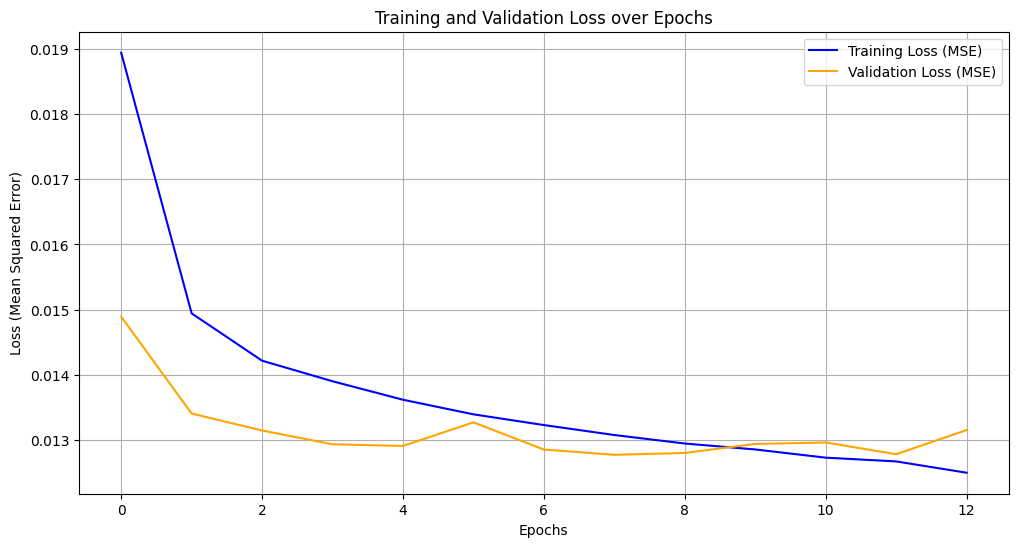

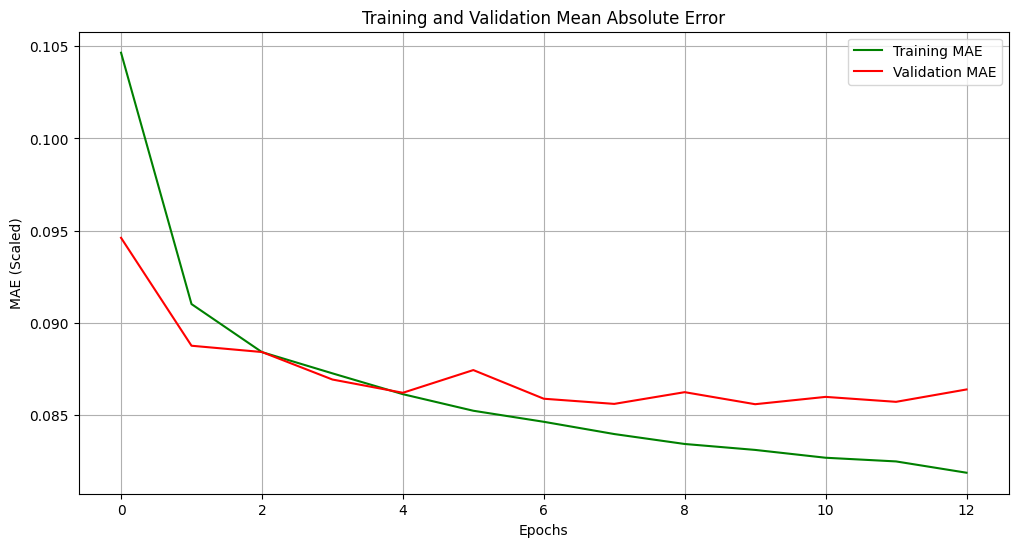

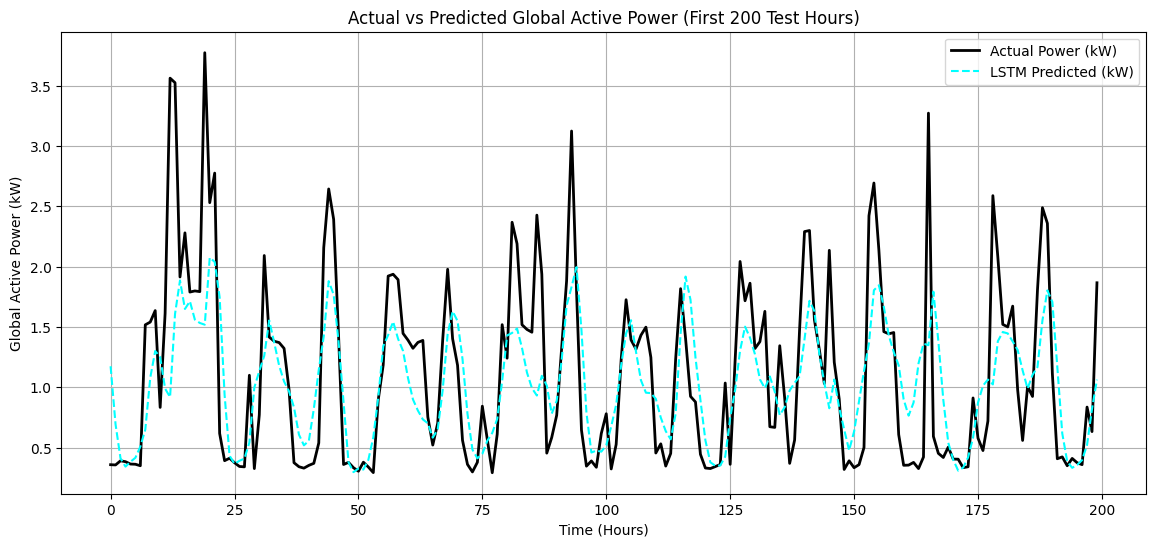

In [4]:
# Graph 1: Loss Curves (MSE)

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 2: MAE Curves

plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Training MAE', color='green')
plt.plot(history.history['val_mae'], label='Validation MAE', color='red')
plt.title('Training and Validation Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('MAE (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 3: Actual vs Predicted (Time Series)

# Since the model predicts 24 hours at a time, plotting all of them creates a messy web. 
# Instead, the standard way to plot a clean line is to take the first hour of every prediction window.

# We take the first 200 hours for a clean zoom-in (like the uploaded image)
subset_n = 200 

# Extract just the 1st hour prediction from each window (index 0)
# This reconstructs a continuous timeline
actual_trace = unscaled_y_test[:subset_n, 0]
pred_trace = unscaled_predictions[:subset_n, 0]

plt.figure(figsize=(14, 6))
plt.plot(actual_trace, label='Actual Power (kW)', color='black', linewidth=2)
plt.plot(pred_trace, label='LSTM Predicted (kW)', color='cyan', linestyle='--')
plt.title(f'Actual vs Predicted Global Active Power (First {subset_n} Test Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()